# registration.ipynb — 3D 모델 / MRI 로드 + 대응 입력 준비 (registration 직접 작성용)

registration(정합)을 직접 구현하기 위한 **입력**을 준비하는 노트북.
- `load_model()`        : 혀 3D 메쉬 → 정점(mm)·면
- `load_mri()`          : MRI 프레임 PNG → grayscale
- `mri_contour()`       : MRI 혀 body **닫힌 윤곽**(image-mm, tip부터 CW)
- `model_contour_cw()`  : 3D 모델 정중시상 **윤곽 landmark**(y=0 슬라이스, tip부터 CW)
- `print_contours()`    : MRI·3D 모델 contour 요약·좌표 출력 (+시각화)

맨 아래 **"여기서부터 직접 작성"**에서 이 둘(`mri_c`, `model_c`)의 대응·정합을 구현하세요.
repo 루트에서 실행.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
import imageio.v2 as imageio
plt.rcParams["figure.dpi"] = 110

REPO = Path.cwd()
assert (REPO/"datasets").exists(), f"repo 루트에서 실행하세요 (현재: {REPO})"
DATA = REPO/"datasets"

# ---- 여기만 바꾸면 됨 ----
SUBJECT   = "Subject3"
FRAME     = 1
OBJ       = DATA/"tongue_model"/"tongue_rest_m.obj"
MM_PER_PX = 1.164
H         = 256
print("config:", SUBJECT, "FRAME", FRAME)

config: Subject3 FRAME 1


## 0. 공통 헬퍼 — CCW·tip 시작 정렬
닫힌 윤곽을 **반시계방향(CCW)** 으로 맞추고 **tip(최소 x)** 을 시작점으로 회전시킵니다.
모델·MRI 윤곽을 같은 규약으로 정렬해야 나중에 점 대응이 맞습니다.

In [2]:
def ccw_from_tip(c):
    """닫힌 윤곽 (K,2) → 반시계(CCW) 방향 + tip(min x) 시작으로 재정렬."""
    c = np.asarray(c, float)
    area = np.sum(c[:, 0]*np.roll(c[:, 1], -1) - np.roll(c[:, 0], -1)*c[:, 1])  # 2×signed area
    if area < 0:                       # 음수면 CW → 뒤집어 CCW
        c = c[::-1]
    c = np.roll(c, -int(np.argmin(c[:, 0])), axis=0)   # tip = 최소 x 를 시작점으로
    return c
print("helper ready")

helper ready


## 1. 3D 모델 로드
`.obj` → 정점(V, mm)·면(F). 파일은 metre 단위라 mm(×1000)+`x+=2.0` 보정(기존 파이프라인 관례).

In [3]:
def load_obj(path):
    V, F = [], []
    for L in open(path):
        t = L.split()
        if not t:
            continue
        if t[0] == "v":
            V.append([float(x) for x in t[1:4]])
        elif t[0] == "f":
            F.append([int(s.split("/")[0]) - 1 for s in t[1:4]])
    return np.array(V, float), np.array(F, int)

def load_model(obj_path=OBJ, to_mm=True, x_shift=2.0):
    V, F = load_obj(str(obj_path))
    if to_mm:
        V = V * 1000.0; V[:, 0] += x_shift
    return V, F

V, F = load_model()
print(f"model: verts {V.shape}, faces {F.shape}  |  x[{V[:,0].min():.0f},{V[:,0].max():.0f}] "
      f"y[{V[:,1].min():.0f},{V[:,1].max():.0f}] z[{V[:,2].min():.0f},{V[:,2].max():.0f}] mm")

model: verts (433, 3), faces (724, 3)  |  x[60,135] y[-34,34] z[55,111] mm


## 2. MRI 이미지 로드
프레임 PNG → grayscale (H,W). `row`=아래+, `col`=오른쪽+.

MRI Subject3 f1: (256, 256) uint8 range[0,255]


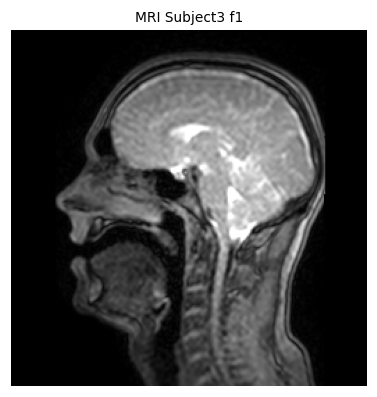

In [4]:
def load_mri(subject=SUBJECT, frame=FRAME, data=DATA):
    png = data/"MRI_SSFP_10fps"/subject/"png"/f"image_{frame}.png"
    if not png.exists():
        raise FileNotFoundError(png)
    img = np.asarray(imageio.imread(str(png)))
    return img[..., 0] if img.ndim == 3 else img

img = load_mri()
print(f"MRI {SUBJECT} f{FRAME}: {img.shape} {img.dtype} range[{img.min()},{img.max()}]")
plt.figure(figsize=(4.2, 4.2)); plt.imshow(img, cmap="gray")
plt.title(f"MRI {SUBJECT} f{FRAME}", fontsize=9); plt.axis("off"); plt.show()

## 3. MRI contour 추출
`extract_body_contour.py` 산출물 `body_contour.npz`에서 프레임별 혀 body **닫힌 윤곽**(subpixel row,col)을
읽어옵니다. 그걸 **image-mm** `(x=col·mm_per_px, y=(H-1-row)·mm_per_px)` 로 바꾸고 **tip부터 CCW**로 정렬.
(원본 마스크에서 새로 뽑고 싶으면 `extract_body_contour.py` 참고 — 여기선 이미 뽑아둔 걸 로드.)

MRI contour: (205, 2) pts (image-mm), tip=[ 65.8 105.9]


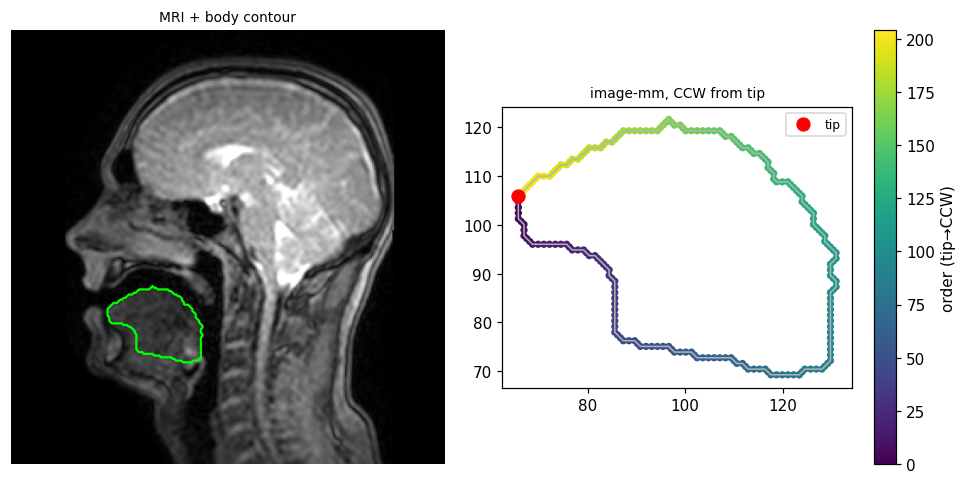

In [5]:
def mri_contour(subject=SUBJECT, frame=FRAME, data=DATA, mm_per_px=MM_PER_PX, h=H):
    """MRI 혀 body 닫힌 윤곽 → image-mm (K,2), tip부터 CCW. dict(rowcol, mm) 반환."""
    npz = np.load(str(data/"MRI_SSFP_10fps"/subject/"body_contour.npz"))
    key = f"contour_f{frame}"
    if key not in npz.files:
        raise KeyError(f"{key} 없음 (사용 가능 프레임 확인)")
    rc = npz[key]                                   # (K,2) row,col subpixel
    xy = np.column_stack([rc[:, 1]*mm_per_px, (h-1-rc[:, 0])*mm_per_px])  # image-mm
    return dict(rowcol=rc, mm=ccw_from_tip(xy))

mri = mri_contour()
mri_c = mri["mm"]                                   # ← registration 입력 (image-mm, CCW from tip)
print(f"MRI contour: {mri_c.shape} pts (image-mm), tip={mri_c[0].round(1)}")

fig, (a0, a1) = plt.subplots(1, 2, figsize=(9, 4.4))
rc = mri["rowcol"]; cc = np.vstack([rc, rc[:1]])
a0.imshow(load_mri(), cmap="gray"); a0.plot(cc[:, 1], cc[:, 0], "-", c="lime", lw=1.5)
a0.set_title("MRI + body contour", fontsize=9); a0.axis("off")
ccm = np.vstack([mri_c, mri_c[:1]])
a1.plot(ccm[:, 0], ccm[:, 1], "-", c="0.7", lw=1)
sc = a1.scatter(mri_c[:, 0], mri_c[:, 1], c=np.arange(len(mri_c)), cmap="viridis", s=14)
a1.scatter(*mri_c[0], c="red", s=70, zorder=5, label="tip")
a1.set_aspect("equal"); a1.legend(fontsize=8); plt.colorbar(sc, ax=a1, label="order (tip→CCW)")
a1.set_title("image-mm, CCW from tip", fontsize=9); plt.tight_layout(); plt.show()

## 4. 3D landmark load — tip부터 반시계방향 vertex 연결
3D 모델의 정중시상 윤곽을 **y=0 평면 슬라이스**(삼각형–평면 교차선을 체인으로 연결)로 뽑습니다.
> raw 정점을 각도로 잇는 방식은 내부점 때문에 **자기교차로 엉킵니다**(실측 확인). 슬라이스가 정답.
결과를 `ccw_from_tip`으로 **tip부터 CCW** 정렬해 순서 있는 landmark 로 만들고 시각화.

3D landmark: (54, 2) pts (model x,z mm), tip=[60.4 99.5]


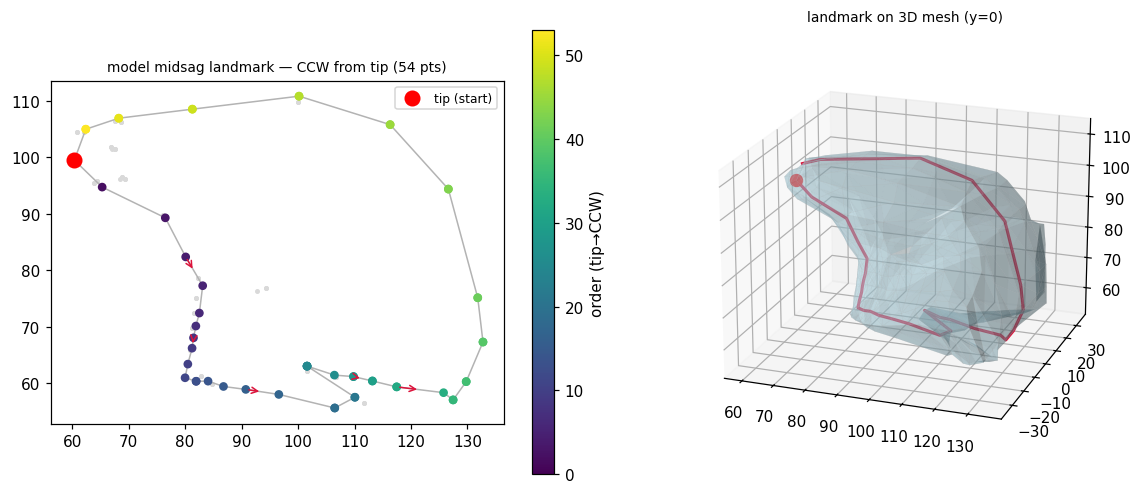

In [6]:
def model_slice_contour(V_mm, F, y=0.0, tol=0.5):
    """tongue mesh 를 y=0 평면으로 잘라 닫힌 정중시상 외곽선 (K,2)=(x,z) mm. 순서 있음."""
    segs = []
    for tri in F:
        p = V_mm[tri]; s = p[:, 1] - y; pts = []
        for a, b in [(0, 1), (1, 2), (2, 0)]:
            if (s[a] <= 0 < s[b]) or (s[b] <= 0 < s[a]):
                t = s[a]/(s[a]-s[b]); pts.append((p[a] + t*(p[b]-p[a]))[[0, 2]])
        if len(pts) == 2:
            segs.append((pts[0], pts[1]))
    used = [False]*len(segs); poly = [np.array(segs[0][0]), np.array(segs[0][1])]; used[0] = True
    for _ in range(len(segs)):
        cur = poly[-1]; nxt = None
        for i, sg in enumerate(segs):
            if used[i]:
                continue
            a, b = np.array(sg[0]), np.array(sg[1])
            if np.hypot(*(a-cur)) < tol: nxt = (i, b); break
            if np.hypot(*(b-cur)) < tol: nxt = (i, a); break
        if nxt is None:
            break
        used[nxt[0]] = True; poly.append(nxt[1])
    return np.array(poly)

def model_contour_ccw(V_mm, F):
    """3D 모델 정중시상 landmark 윤곽 (K,2)=(x,z) mm, tip부터 CCW."""
    return ccw_from_tip(model_slice_contour(V_mm, F))

model_c = model_contour_ccw(V, F)                  # ← registration 입력 (model x,z mm, CCW from tip)
print(f"3D landmark: {model_c.shape} pts (model x,z mm), tip={model_c[0].round(1)}")

fig = plt.figure(figsize=(11, 4.6))
a0 = fig.add_subplot(1, 2, 1)
cc = np.vstack([model_c, model_c[:1]]); a0.plot(cc[:, 0], cc[:, 1], "-", c="0.7", lw=1)
sc = a0.scatter(model_c[:, 0], model_c[:, 1], c=np.arange(len(model_c)), cmap="viridis", s=22, zorder=3)
a0.scatter(*model_c[0], c="red", s=90, zorder=5, label="tip (start)")
for k in range(0, len(model_c), max(1, len(model_c)//12)):    # 방향 화살표
    d = model_c[(k+1) % len(model_c)] - model_c[k]
    a0.annotate("", model_c[k]+d*0.5, model_c[k], arrowprops=dict(arrowstyle="->", color="crimson"))
mid = V[np.abs(V[:, 1]) < 6.0]; a0.scatter(mid[:, 0], mid[:, 2], s=5, c="0.85", zorder=0)
a0.set_aspect("equal"); a0.legend(fontsize=8); plt.colorbar(sc, ax=a0, label="order (tip→CCW)")
a0.set_title(f"model midsag landmark — CCW from tip ({len(model_c)} pts)", fontsize=9)
a1 = fig.add_subplot(1, 2, 2, projection="3d")
a1.plot_trisurf(V[:, 0], V[:, 1], V[:, 2], triangles=F, color="lightblue", alpha=0.35, linewidth=0.1, edgecolor="0.7")
a1.plot(model_c[:, 0], np.zeros(len(model_c)), model_c[:, 1], "-", c="crimson", lw=2)
a1.scatter([model_c[0, 0]], [0], [model_c[0, 1]], c="red", s=60)
a1.view_init(20, -70); a1.set_title("landmark on 3D mesh (y=0)", fontsize=9)
plt.tight_layout(); plt.show()

## 4a. MRI / 3D 모델 contour 출력
`print_contours()` — MRI body contour(row,col · image-mm)와 3D 모델 midsag contour(x,z mm)를
요약·좌표로 출력하고, 선택적으로 나란히 시각화합니다.

In [7]:
def print_contours(subject=SUBJECT, frame=FRAME, V_mm=None, F=None,
                   data=DATA, mm_per_px=MM_PER_PX, h=H,
                   max_pts=None, show_plot=True):
    """MRI contour와 3D model contour를 요약·좌표 출력 (+선택 시각화).

    Parameters
    ----------
    max_pts : int or None
        좌표를 몇 점까지 출력할지. None이면 전체.
    show_plot : bool
        True면 MRI·모델 contour를 나란히 그림.

    Returns
    -------
    dict with keys ``mri`` (rowcol, mm), ``model`` (x,z mm, CW from tip).
    """
    if V_mm is None or F is None:
        V_mm, F = load_model()

    mri = mri_contour(subject=subject, frame=frame, data=data,
                      mm_per_px=mm_per_px, h=h)
    model_c = model_contour_cw(V_mm, F)
    mri_rc, mri_mm = mri["rowcol"], mri["mm"]

    print(f"=== MRI contour  {subject}  frame {frame} ===")
    print(f"  points     : {len(mri_rc)}")
    print(f"  row,col    : row [{mri_rc[:, 0].min():6.1f}, {mri_rc[:, 0].max():6.1f}]"
          f"  col [{mri_rc[:, 1].min():6.1f}, {mri_rc[:, 1].max():6.1f}]")
    print(f"  image-mm   : x [{mri_mm[:, 0].min():6.1f}, {mri_mm[:, 0].max():6.1f}]"
          f"  y [{mri_mm[:, 1].min():6.1f}, {mri_mm[:, 1].max():6.1f}]")
    print(f"  tip (start): row={mri_rc[0, 0]:.2f} col={mri_rc[0, 1]:.2f}"
          f"  |  x={mri_mm[0, 0]:.2f} y={mri_mm[0, 1]:.2f} mm")

    print(f"\n=== 3D model contour  (midsag y=0, CW from tip) ===")
    print(f"  points     : {len(model_c)}")
    print(f"  model x,z  : x [{model_c[:, 0].min():6.1f}, {model_c[:, 0].max():6.1f}]"
          f"  z [{model_c[:, 1].min():6.1f}, {model_c[:, 1].max():6.1f}] mm")
    print(f"  tip (start): x={model_c[0, 0]:.2f} z={model_c[0, 1]:.2f} mm")

    n_mri = len(mri_rc) if max_pts is None else min(max_pts, len(mri_rc))
    n_mod = len(model_c) if max_pts is None else min(max_pts, len(model_c))
    print(f"\n--- MRI points (idx  row    col  |  x_mm   y_mm)  [{n_mri}/{len(mri_rc)}] ---")
    for i in range(n_mri):
        print(f"  [{i:4d}]  {mri_rc[i, 0]:7.2f} {mri_rc[i, 1]:7.2f}"
              f"  |  {mri_mm[i, 0]:7.2f} {mri_mm[i, 1]:7.2f}")
    if max_pts is not None and n_mri < len(mri_rc):
        print(f"  ... ({len(mri_rc) - n_mri} more)")

    print(f"\n--- 3D model points (idx  x_mm   z_mm)  [{n_mod}/{len(model_c)}] ---")
    for i in range(n_mod):
        print(f"  [{i:4d}]  {model_c[i, 0]:7.2f} {model_c[i, 1]:7.2f}")
    if max_pts is not None and n_mod < len(model_c):
        print(f"  ... ({len(model_c) - n_mod} more)")

    if show_plot:
        fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
        g = load_mri(subject=subject, frame=frame, data=data)
        rc = mri_rc; cc = np.vstack([rc, rc[:1]])
        axes[0].imshow(g, cmap="gray")
        axes[0].plot(cc[:, 1], cc[:, 0], "-", c="lime", lw=1.4)
        axes[0].scatter(rc[0, 1], rc[0, 0], c="red", s=50, zorder=5)
        axes[0].set_title(f"MRI f{frame} (row,col)", fontsize=9); axes[0].axis("off")

        cmm = np.vstack([mri_mm, mri_mm[:1]])
        axes[1].plot(cmm[:, 0], cmm[:, 1], "-", c="0.7", lw=1)
        axes[1].scatter(mri_mm[:, 0], mri_mm[:, 1], c=np.arange(len(mri_mm)),
                        cmap="viridis", s=10)
        axes[1].scatter(*mri_mm[0], c="red", s=60, zorder=5)
        axes[1].set_aspect("equal")
        axes[1].set_title("MRI image-mm (CW from tip)", fontsize=9)

        cmod = np.vstack([model_c, model_c[:1]])
        axes[2].plot(cmod[:, 0], cmod[:, 1], "-", c="0.7", lw=1)
        axes[2].scatter(model_c[:, 0], model_c[:, 1], c=np.arange(len(model_c)),
                        cmap="viridis", s=14)
        axes[2].scatter(*model_c[0], c="red", s=70, zorder=5)
        mid = V_mm[np.abs(V_mm[:, 1]) < 6.0]
        axes[2].scatter(mid[:, 0], mid[:, 2], s=4, c="0.85", zorder=0)
        axes[2].set_aspect("equal")
        axes[2].set_title("3D model x,z mm (CW from tip)", fontsize=9)
        fig.suptitle(f"{subject} f{frame} — MRI vs 3D model contour", fontsize=10)
        fig.tight_layout(); plt.show()

    return dict(mri=mri, model=model_c)

# 예: 전체 좌표 출력
contours = print_contours()
# 예: 앞 10점만 출력, 그림 생략
# contours = print_contours(max_pts=10, show_plot=False)

NameError: name 'model_contour_cw' is not defined

## 4b. 랜드마크 vertex 직접 지정
자동 tip/dorsum/root 대신, **원하는 vertex 인덱스를 눈으로 읽어 직접 지정**합니다.
아래 그림에서 정중시상(`|y|<tol`) 정점마다 **인덱스**가 붙어 있으니, tip·dorsum·root(그 외도 가능)에
해당하는 번호를 읽어 다음 셀 `LANDMARK_VERTS`에 넣으세요. `tol`을 키우면 더 많은 정점이 보입니다.

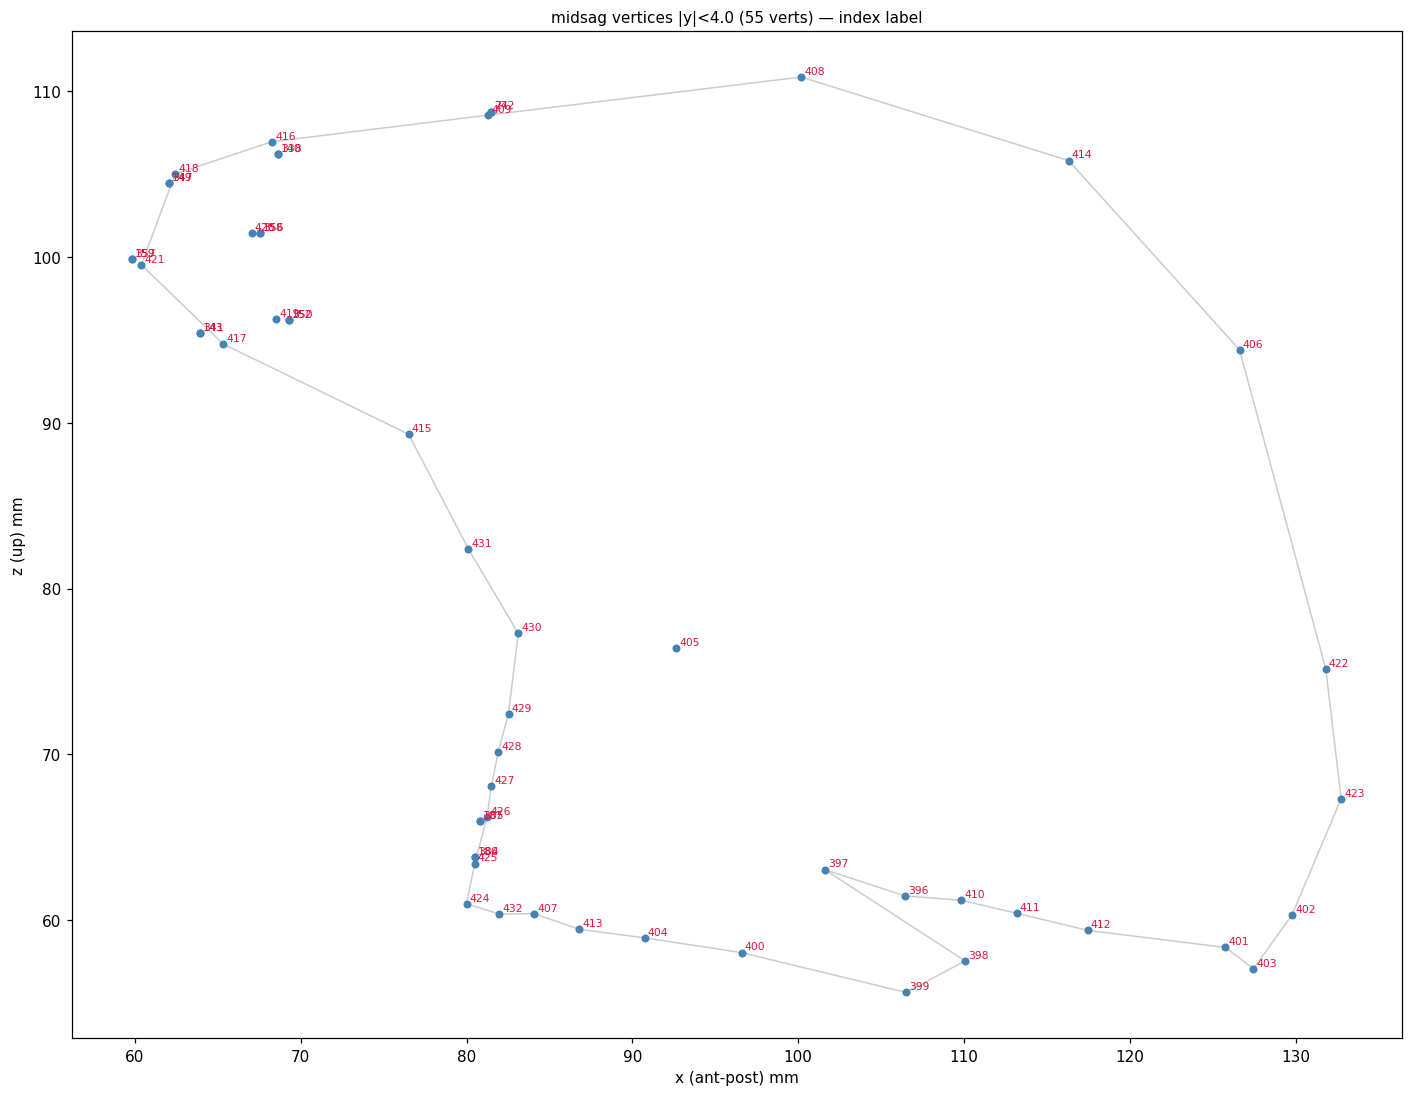

In [ ]:
def plot_vertex_ids(V, F, tol=4.0, figsize=(13, 10)):
    """정중시상(|y|<tol) 정점을 (x,z)에 인덱스 라벨과 함께 표시. 슬라이스 윤곽을 밑그림으로."""
    ids = np.where(np.abs(V[:, 1]) < tol)[0]
    sc = model_slice_contour(V, F); cc = np.vstack([sc, sc[:1]])
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(cc[:, 0], cc[:, 1], "-", c="0.8", lw=1, zorder=0)
    ax.scatter(V[ids, 0], V[ids, 2], c="steelblue", s=18, zorder=3)
    for i in ids:
        ax.annotate(str(i), (V[i, 0], V[i, 2]), fontsize=7, color="crimson",
                    xytext=(2, 2), textcoords="offset points")
    ax.set_aspect("equal"); ax.set_xlabel("x (ant-post) mm"); ax.set_ylabel("z (up) mm")
    ax.set_title(f"midsag vertices |y|<{tol} ({len(ids)} verts) — index label", fontsize=10)
    plt.tight_layout(); plt.show()
    return ids

def nearest_vertex(x, z, tol=6.0):
    """(x,z) 좌표에서 가장 가까운 정중시상 정점 인덱스 찾기(라벨이 겹칠 때 확인용)."""
    ids = np.where(np.abs(V[:, 1]) < tol)[0]
    k = ids[np.argmin(np.hypot(V[ids, 0]-x, V[ids, 2]-z))]
    print(f"nearest vertex = {k}  (x={V[k,0]:.1f}, z={V[k,2]:.1f})"); return int(k)

vids = plot_vertex_ids(V, F, tol=4.0)
# 참고: 문서 기존 midsag_indices(tip→root) = [418,416,409,408,414,406,422]

### 랜드마크 vertex 지정 & 확인
위 그림에서 읽은 번호를 `LANDMARK_VERTS`에 넣으세요(순서는 tip→dorsum→root 권장).
실행하면 선택 정점을 2D·3D에 강조하고 좌표를 출력하며, `model_lm (K,2)=(x,z) mm`를 만듭니다.

  tip      = v418: x=  62.4 y=   0.0 z= 105.0 mm
  dorsum   = v408: x= 100.2 y=   0.0 z= 110.9 mm
  root     = v422: x= 131.8 y=   0.0 z=  75.2 mm


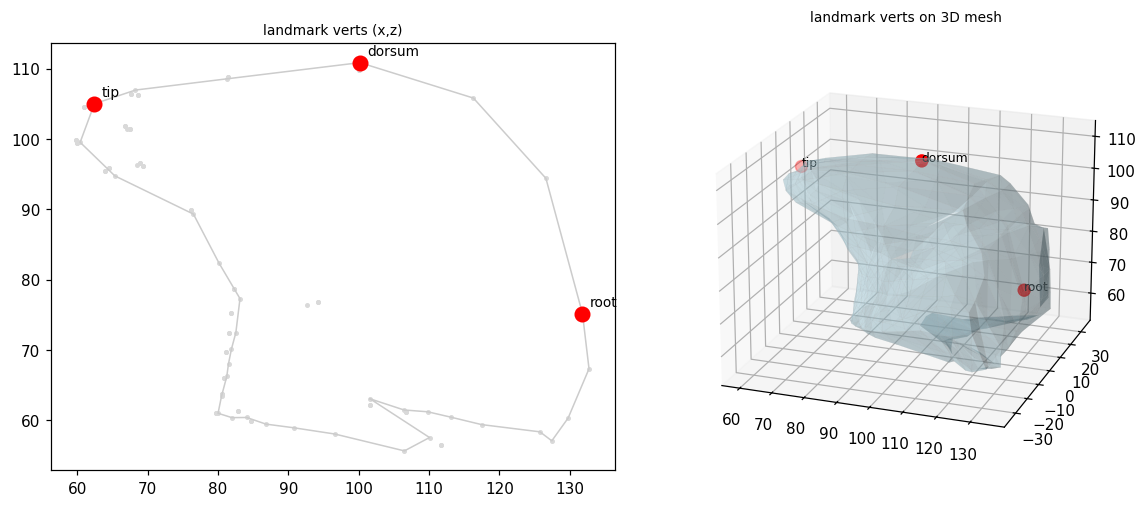

model_lm (x,z) mm:
 [[ 62.4 105. ]
 [100.2 110.8]
 [131.8  75.2]]


In [ ]:
# ← 여기에 직접 지정 (아래는 예시 기본값: 문서 dorsal 라인 기준)
LANDMARK_VERTS = {"tip": 418, "dorsum": 408, "root": 422}

def show_landmarks(V, F, landmark_verts):
    """지정 랜드마크 정점을 강조 시각화 + 좌표 출력. 반환 (names, ids, model_lm(x,z))."""
    names = list(landmark_verts.keys()); ids = [landmark_verts[n] for n in names]
    lm = V[ids][:, [0, 2]]                       # (K,2) model x,z mm
    for n, i in zip(names, ids):
        print(f"  {n:8s} = v{i}: x={V[i,0]:6.1f} y={V[i,1]:6.1f} z={V[i,2]:6.1f} mm")
    sc = model_slice_contour(V, F); cc = np.vstack([sc, sc[:1]])
    fig = plt.figure(figsize=(11, 4.6))
    a0 = fig.add_subplot(1, 2, 1)
    a0.plot(cc[:, 0], cc[:, 1], "-", c="0.8", lw=1)
    mid = V[np.abs(V[:, 1]) < 6.0]; a0.scatter(mid[:, 0], mid[:, 2], s=5, c="0.85", zorder=0)
    a0.scatter(lm[:, 0], lm[:, 1], c="red", s=90, zorder=5)
    for n, (x, z) in zip(names, lm):
        a0.annotate(n, (x, z), color="k", fontsize=9, xytext=(5, 5), textcoords="offset points")
    a0.set_aspect("equal"); a0.set_title("landmark verts (x,z)", fontsize=9)
    a1 = fig.add_subplot(1, 2, 2, projection="3d")
    a1.plot_trisurf(V[:, 0], V[:, 1], V[:, 2], triangles=F, color="lightblue", alpha=0.3, linewidth=0.1, edgecolor="0.7")
    a1.scatter(V[ids, 0], V[ids, 1], V[ids, 2], c="red", s=60)
    for n, i in zip(names, ids):
        a1.text(V[i, 0], V[i, 1], V[i, 2], n, fontsize=8)
    a1.view_init(20, -70); a1.set_title("landmark verts on 3D mesh", fontsize=9)
    plt.tight_layout(); plt.show()
    return names, ids, lm

lm_names, lm_ids, model_lm = show_landmarks(V, F, LANDMARK_VERTS)
print("model_lm (x,z) mm:\n", model_lm.round(1))

### (선택) 인터랙티브로 vertex 집기 — plotly hover
plotly가 설치돼 있으면, 3D 메쉬 위 정점에 **마우스를 올리면 인덱스·좌표**가 뜹니다. 집어서 위 dict에 넣기 편해요.

In [ ]:
try:
    import plotly.graph_objects as go
    mtol = np.abs(V[:, 1]) < 8.0
    ids = np.where(mtol)[0]
    fig = go.Figure()
    fig.add_trace(go.Mesh3d(x=V[:, 0], y=V[:, 1], z=V[:, 2],
                            i=F[:, 0], j=F[:, 1], k=F[:, 2], opacity=0.25, color="lightblue"))
    fig.add_trace(go.Scatter3d(x=V[ids, 0], y=V[ids, 1], z=V[ids, 2], mode="markers",
                               marker=dict(size=3, color="crimson"),
                               text=[f"v{i}" for i in ids],
                               hovertemplate="%{text}<br>x=%{x:.1f} y=%{y:.1f} z=%{z:.1f}<extra></extra>"))
    fig.update_layout(height=600, title="hover a vertex to read its index (midsag |y|<8)")
    fig.show()
except Exception as e:
    print("plotly 없음 → 위 정적 라벨 그림/`nearest_vertex(x,z)` 사용:", e)

plotly 없음 → 위 정적 라벨 그림/`nearest_vertex(x,z)` 사용: No module named 'plotly'


## 여기서부터 registration 직접 작성 ✍️

준비된 입력:
- `V (N,3)`, `F (M,3)` — 3D 모델 정점(mm)·면
- `img (H,W)` — MRI grayscale
- `mri_c (K,2)` — MRI 혀 윤곽, **image-mm**, tip부터 CCW
- `model_c (K',2)` — 3D 정중시상 landmark 윤곽, **model (x,z) mm**, tip부터 CCW
- `LANDMARK_VERTS`, `model_lm (K,2)` — **직접 지정한** 랜드마크 정점(model x,z mm)

목표: image-mm `(x,y)` → model `(x,z)` 매핑(affine/similarity 등)을 찾기.
직접 지정한 `model_lm`과 MRI 쪽 대응점(예: `mri_c`에서 같은 해부학 위치)을 짝지어 fit 하면 됩니다.

In [8]:
# 기본: 전체 좌표 출력 + 시각화
contours = print_contours()

# 앞 10점만 출력, 그림 생략
contours = print_contours(max_pts=10, show_plot=False)

# 다른 프레임
contours = print_contours(subject="Subject3", frame=30)

NameError: name 'model_contour_cw' is not defined